In [100]:
%pip install pandas numpy scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [102]:
# 1. Load data
# -----------------------
df = pd.read_csv("Dataset_14-day_AA_depression_symptoms_mood_and_PHQ-9.csv")
df.columns = df.columns.str.strip()

In [103]:
df.tail(5)

,Unnamed: 0,user_id,phq1,phq2,phq3,phq4,phq5,phq6,phq7,phq8,...,q14,q16,q46,q47,happiness.score,time,period.name,start.time,phq.day,id
16145,16146,185,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,3,2017-02-04 10:44:56,morning,2017-01-07 18:55:29,11.632975,185
16146,16147,185,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,3,2017-01-29 22:00:47,evening,2017-01-07 18:55:29,6.102315,185
16147,16148,185,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,0.0,3,2017-01-18 18:30:06,evening,2017-01-07 18:55:29,-5.043993,185
16148,16149,185,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,NaN,NaN,NaN,3,2017-01-22 10:36:42,morning,2017-01-07 18:55:29,-1.372743,185
16149,16150,185,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,3,2017-01-08 15:01:18,midday,2017-01-07 18:55:29,-15.188993,185


In [104]:
# PHQ questions (main depression features)
phq_cols = [f"phq{i}" for i in range(1, 10)]

# EMA daily questions (q columns)
q_cols = [
    "q1","q2","q3","q4","q5","q6","q7","q8","q9",
    "q10","q11","q12","q13","q14","q16","q46","q47"
]

keep_cols = [
    "user_id",
    "age",
    "sex",
    "happiness.score",
    "time",
    "period.name",
    "phq.day"
] + phq_cols + q_cols

df = df[keep_cols]

In [105]:
for col in phq_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())


In [106]:
# PHQ total score
df["phq_total"] = df[phq_cols].sum(axis=1)

# Depression label from PHQ
def label(x):
    if x <= 4:
        return 0
    elif x <= 9:
        return 1
    elif x <= 14:
        return 2
    else:
        return 3

df["depression_target"] = df["phq_total"].apply(label)

In [107]:

for col in q_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

    # answered or not feature
    df[col + "_answered"] = df[col].notna().astype(int)

    # fill NaN using median
    df[col] = df[col].fillna(df[col].median())

In [108]:

# happiness score
df["happiness.score"] = pd.to_numeric(
    df["happiness.score"],
    errors="coerce"
)
df["happiness.score"] = df["happiness.score"].fillna(
    df["happiness.score"].median()
)

# age
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["age"] = df["age"].fillna(df["age"].median())

# phq.day
df["phq.day"] = pd.to_numeric(df["phq.day"], errors="coerce")
df["phq.day"] = df["phq.day"].fillna(df["phq.day"].median())

In [109]:
 #6. ENCODE SEX

df["sex"] = df["sex"].fillna(df["sex"].mode()[0])

df["sex"] = df["sex"].map({
    "male": 0,
    "female": 1
})

df["sex"] = df["sex"].fillna(0)

In [110]:
# 7. TIME CONVERSION + SORTING
# =========================================

df["time"] = pd.to_datetime(df["time"], errors="coerce")

# VERY IMPORTANT for time series
df = df.sort_values(["user_id", "time"])

In [111]:
# Better time-based features
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["hour"] = df["time"].dt.hour
df["weekday"] = df["time"].dt.dayofweek

In [112]:
# Fill missing values
df["month"] = df["month"].fillna(df["month"].median())
df["day"] = df["day"].fillna(df["day"].median())
df["hour"] = df["hour"].fillna(df["hour"].median())
df["weekday"] = df["weekday"].fillna(df["weekday"].median())


In [113]:
# 10. ENCODE PERIOD.NAME
# =========================================

df = pd.get_dummies(
    df,
    columns=["period.name"],
    dtype=int
)


In [114]:
# 12. TRUE TIME-SERIES FEATURE
# (ONLY HAPPINESS)
# =====================================

df["prev_happiness"] = (
    df.groupby("user_id")["happiness.score"]
    .shift(1)
)

df["rolling_happiness"] = (
    df.groupby("user_id")["happiness.score"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

df["happiness_trend"] = (
    df.groupby("user_id")["happiness.score"]
    .diff()
)

df["time_diff"] = (
    df.groupby("user_id")["time"]
    .diff()
    .dt.total_seconds()
)



In [115]:
# 13. FILL NaNs
# =====================================

df["prev_happiness"] = df["prev_happiness"].fillna(
    df["happiness.score"]
)

df["rolling_happiness"] = df["rolling_happiness"].fillna(
    df["happiness.score"]
)

df["happiness_trend"] = df["happiness_trend"].fillna(0)

df["time_diff"] = df["time_diff"].fillna(
    df["time_diff"].median()
)


# =====================================
# 14. DROP ORIGINAL TIME
# =====================================

df.drop(columns=["time"], inplace=True)


# =====================================
# 15. FINAL X and y
# =====================================

# safety: ensure columns exist
drop_cols = ["user_id"]

# X = features
X = df.drop(columns=[col for col in drop_cols if col in df.columns])

# y = depression target (MAIN MODEL)
y = df["depression_target"]

In [116]:

df["age"].nunique()
df["sex"].nunique()

2

In [117]:
df.head(5)

,user_id,age,sex,happiness.score,phq.day,phq1,phq2,phq3,phq4,phq5,...,day,hour,weekday,period.name_evening,period.name_midday,period.name_morning,prev_happiness,rolling_happiness,happiness_trend,time_diff
43,1,29.0,1.0,1,-14.486204,3.0,3.0,3.0,3.0,2.0,...,9,7,0,0,0,1,1.0,1.000000,0.0,32249.0
42,1,29.0,1.0,0,-10.002766,3.0,3.0,3.0,3.0,2.0,...,13,18,4,1,0,0,1.0,1.000000,-1.0,387369.0
19,1,29.0,1.0,2,-9.160775,3.0,3.0,3.0,3.0,2.0,...,14,15,5,0,1,0,0.0,0.500000,2.0,72748.0
41,1,29.0,1.0,2,-8.900208,3.0,3.0,3.0,3.0,2.0,...,14,21,5,1,0,0,2.0,1.000000,0.0,22513.0
33,1,29.0,1.0,3,-8.289155,3.0,3.0,3.0,3.0,2.0,...,15,12,6,0,1,0,2.0,1.333333,1.0,52795.0


In [118]:
df["happiness.score"].value_counts()

happiness.score
2    6550
3    3696
1    3633
0    1900
4     371
Name: count, dtype: int64

In [119]:
print("Dataset columns:", df.columns.tolist())

Dataset columns: ['user_id', 'age', 'sex', 'happiness.score', 'phq.day', 'phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12', 'q13', 'q14', 'q16', 'q46', 'q47', 'phq_total', 'depression_target', 'q1_answered', 'q2_answered', 'q3_answered', 'q4_answered', 'q5_answered', 'q6_answered', 'q7_answered', 'q8_answered', 'q9_answered', 'q10_answered', 'q11_answered', 'q12_answered', 'q13_answered', 'q14_answered', 'q16_answered', 'q46_answered', 'q47_answered', 'month', 'day', 'hour', 'weekday', 'period.name_evening', 'period.name_midday', 'period.name_morning', 'prev_happiness', 'rolling_happiness', 'happiness_trend', 'time_diff']


In [120]:
df[["user_id", "phq_total", "depression_target"]].tail(5)

,user_id,phq_total,depression_target
16139,185,5.0,1
16132,185,5.0,1
16124,185,5.0,1
16114,185,5.0,1
16108,185,5.0,1


In [121]:
df["depression_target"].unique()

array([3, 1, 2, 0])

In [122]:
df["depression_target"].nunique()

4

rolling_happiness     -0.391715
happiness.score       -0.340199
prev_happiness        -0.339628
age                   -0.142065
user_id               -0.057035
phq.day               -0.055966
month                 -0.051996
q16_answered          -0.005228
q7_answered           -0.004778
q14_answered          -0.003571
period.name_evening   -0.003346
time_diff             -0.003233
period.name_midday    -0.001513
happiness_trend       -0.001261
q8_answered           -0.001047
q3_answered           -0.001031
q11_answered          -0.000862
q12_answered          -0.000835
hour                  -0.000597
q1_answered           -0.000447
q46_answered           0.000485
q9_answered            0.000495
q5_answered            0.000520
q47_answered           0.000594
weekday                0.000678
q10_answered           0.000980
q13_answered           0.001421
q2_answered            0.001685
q6_answered            0.002801
q4_answered            0.002941
day                    0.003722
period.n

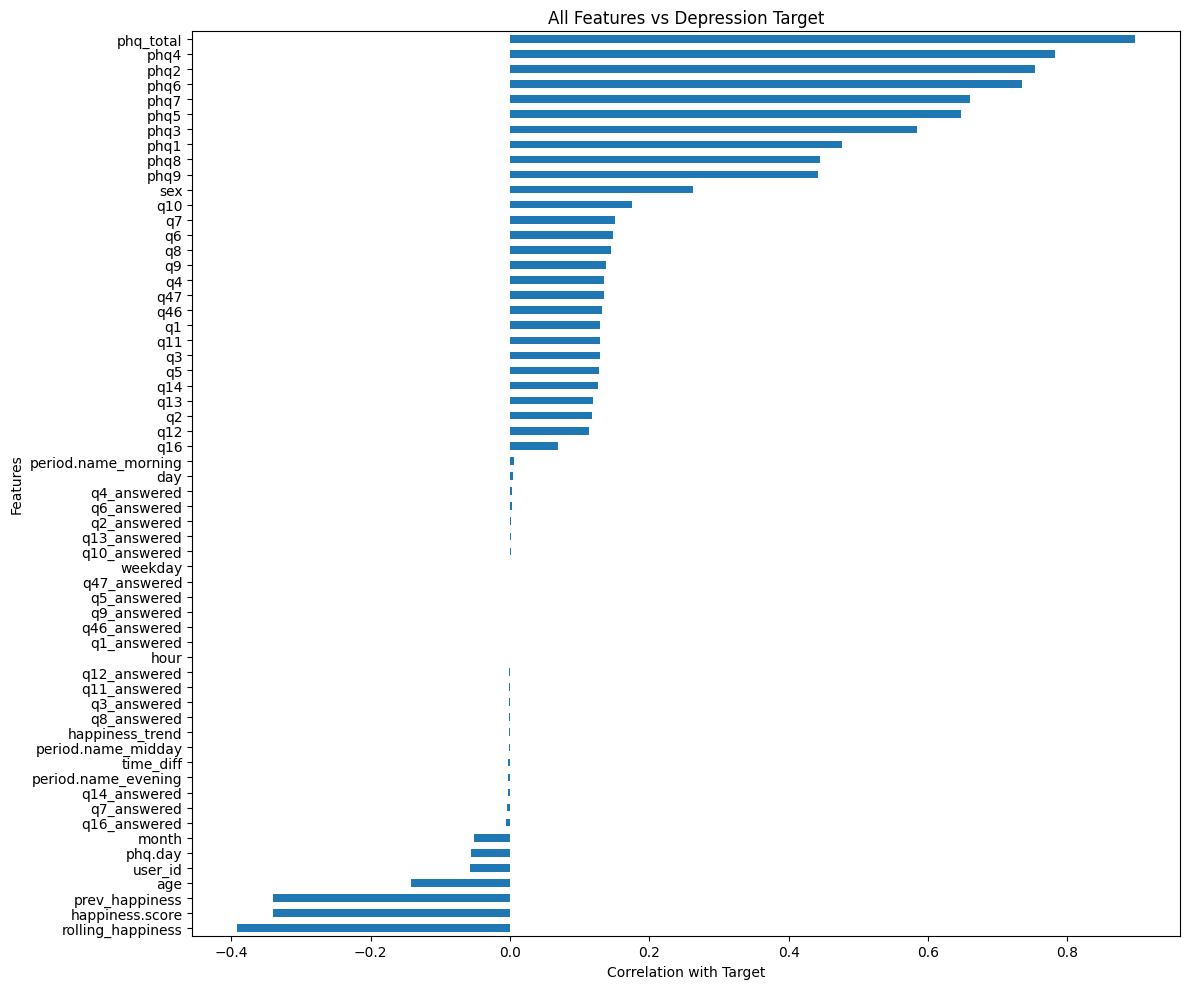

In [123]:
# Keep only numeric columns
numeric_df = df.select_dtypes(include=["number"])

# Correlation with target
corr_with_target = numeric_df.corr()["depression_target"]

# Remove target itself
corr_with_target = corr_with_target.drop("depression_target")

# Sort values
corr_with_target = corr_with_target.sort_values()

# Print values
print(corr_with_target)

# Plot graph
plt.figure(figsize=(12,10))

corr_with_target.plot(kind="barh")

plt.title("All Features vs Depression Target")
plt.xlabel("Correlation with Target")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

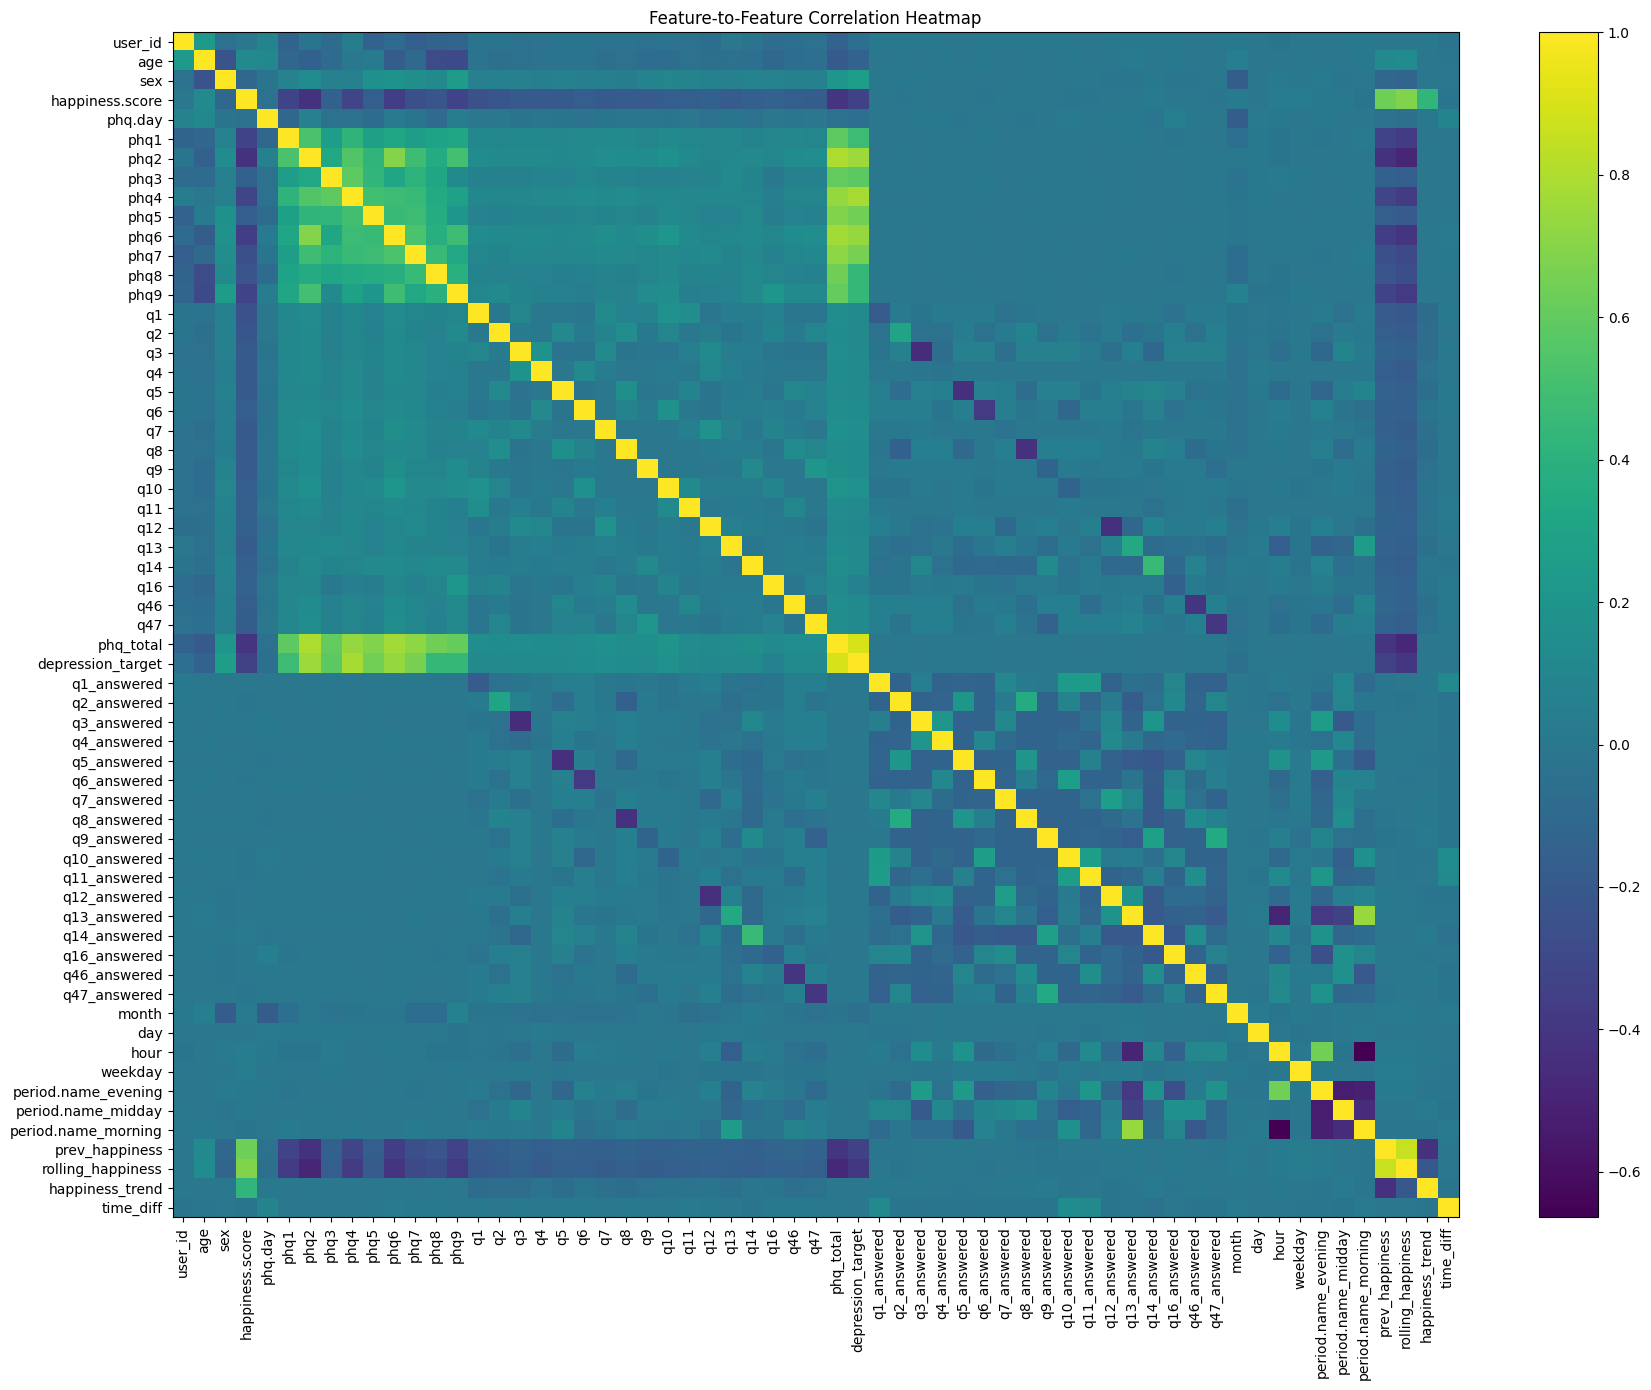

In [124]:
numeric_df = df.select_dtypes(include=["number"])

# correlation matrix
corr_matrix = numeric_df.corr()

# plot heatmap
plt.figure(figsize=(18, 14))

plt.imshow(corr_matrix, aspect='auto')

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Feature-to-Feature Correlation Heatmap")

plt.tight_layout()
plt.show()


In [125]:
# =====================================
# REMOVE WEAK / USELESS COLUMNS
# =====================================

remove_cols = [
    # never use in X
    "user_id",
    "phq_total",
    "depression_target",

    # answered flags (mostly useless)
    "q1_answered",
    "q2_answered",
    "q3_answered",
    "q4_answered",
    "q5_answered",
    "q6_answered",
    "q7_answered",
    "q8_answered",
    "q9_answered",
    "q10_answered",
    "q11_answered",
    "q12_answered",
    "q13_answered",
    "q14_answered",
    "q16_answered",
    "q46_answered",
    "q47_answered",

    # weak calendar features
    "month",
    "day",
    "weekday",

    # weak period features
    "period.name_morning",
    "period.name_midday",
    "period.name_evening"
]

# remove only if column exists
X = df.drop(
    columns=[col for col in remove_cols if col in df.columns]
)

# target
y = df["depression_target"]

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print(X.columns.tolist())

Final X shape: (16150, 35)
Final y shape: (16150,)
['age', 'sex', 'happiness.score', 'phq.day', 'phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12', 'q13', 'q14', 'q16', 'q46', 'q47', 'hour', 'prev_happiness', 'rolling_happiness', 'happiness_trend', 'time_diff']


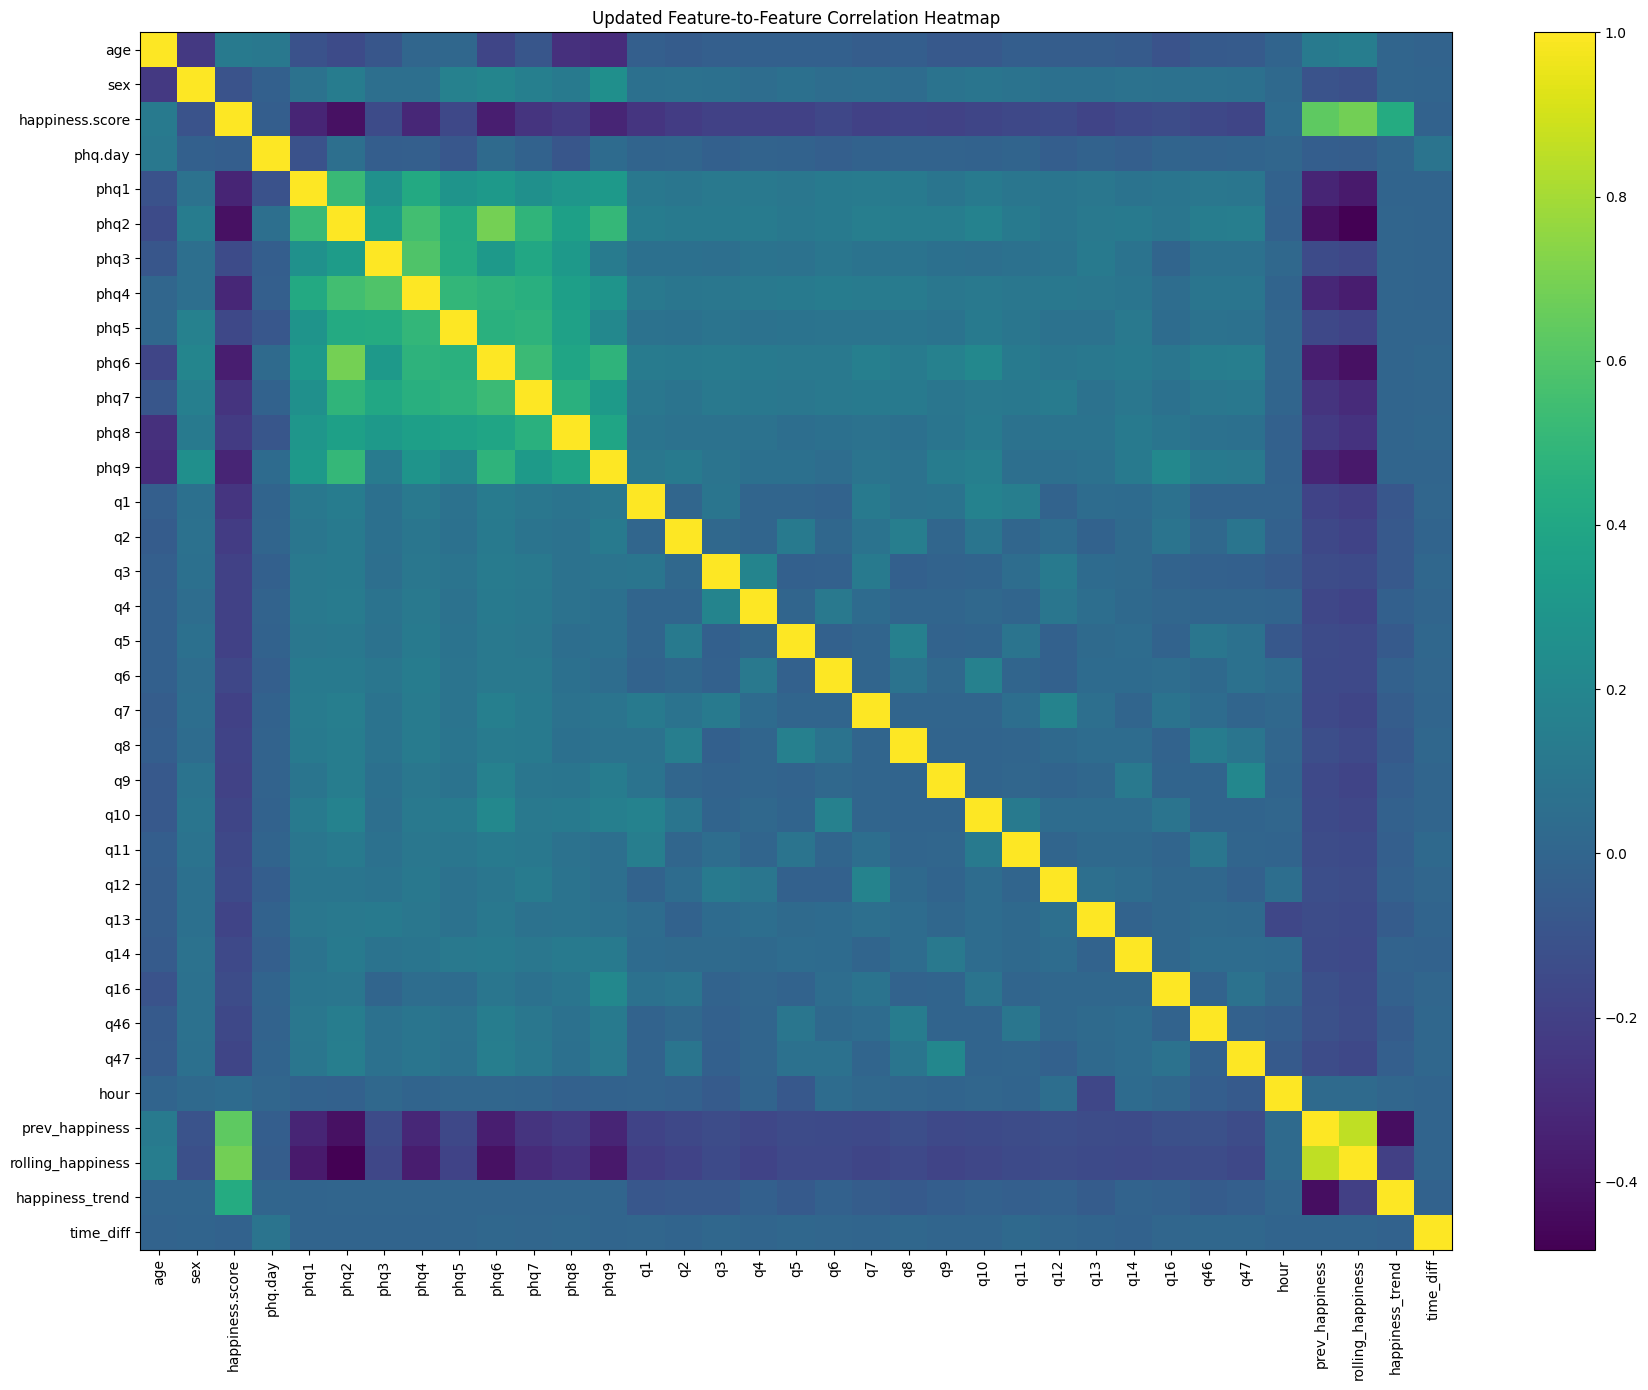

In [127]:
# =====================================
# UPDATED HEATMAP (after removing weak columns)
# =====================================

import matplotlib.pyplot as plt

# use only final useful columns + target
heatmap_df = df.drop(
    columns=[col for col in remove_cols if col in df.columns]
)

# keep only numeric columns
heatmap_df = heatmap_df.select_dtypes(include=["number"])

# correlation matrix
corr_matrix = heatmap_df.corr()

# plot heatmap
plt.figure(figsize=(18, 14))

plt.imshow(corr_matrix, aspect='auto')

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Updated Feature-to-Feature Correlation Heatmap")

plt.tight_layout()
plt.show()